In [1]:
import pandas as pd

df1 = pd.read_csv('../../dataset-generation/cryst-unnormalized-5000ep-ppo-default-500.csv')
df2 = pd.read_csv('../../dataset-generation/cryst-unnormalized-5000ep-ppo-default-30000.csv')
df3 = pd.read_csv('../../dataset-generation/cryst-unnormalized-5000ep-random.csv')
print(df1.head(20))
print('-'*50)
print(df2.head(20))
print('-'*50)
print(df3.head(20))
print('-'*50)
print(df1.shape, df2.shape, df3.shape)

            mu0            mu1          mu2         C        CV         Ln  \
0   1500.000000   23000.000000   1800000.00  0.160000  1.000000  15.000000   
1   1500.000000   23000.000000   1800000.00  0.160000  1.000000  15.000000   
2   1500.000000   23000.000000   1800000.00  0.160000  1.000000  15.000000   
3   1500.000000   23000.000000   1800000.00  0.160000  1.000000  15.000000   
4   1753.685913   48816.582031   3005200.25  0.159571  0.074865  27.503227   
5   1753.685913   48816.582031   3005200.25  0.159571  0.074865  27.503227   
6   1753.685913   48816.582031   3005200.25  0.159571  0.074865  27.503227   
7   1753.685913   48816.582031   3005200.25  0.159571  0.074865  27.503227   
8   2206.455078   80213.414062   5138588.00  0.158856 -0.152808  36.020634   
9   2206.462402   80213.578125   5138600.50  0.158856 -0.152807  36.020599   
10  2206.467529   80213.687500   5138607.50  0.158856 -0.152806  36.020573   
11  2206.447510   80213.140625   5138570.50  0.158856 -0.152808 

In [2]:
df = pd.concat([df1, df2,df3], axis=0)
df

,mu0,mu1,mu2,C,CV,Ln,CV_SP,Ln_SP,mu3
0,1500.000000,2.300000e+04,1.800000e+06,0.160000,1.000000,15.000000,1.0,15.0,2.500000e+08
1,1500.000000,2.300000e+04,1.800000e+06,0.160000,1.000000,15.000000,1.0,15.0,2.500000e+08
2,1500.000000,2.300000e+04,1.800000e+06,0.160000,1.000000,15.000000,1.0,15.0,2.500000e+08
3,1500.000000,2.300000e+04,1.800000e+06,0.160000,1.000000,15.000000,1.0,15.0,2.500000e+08
4,1753.685913,4.881658e+04,3.005200e+06,0.159571,0.074865,27.503227,1.0,15.0,3.790643e+08
...,...,...,...,...,...,...,...,...,...
144995,336200.375000,5.059848e+06,2.459005e+08,0.081437,0.467194,14.716766,1.0,15.0,2.386137e+10
144996,347912.031250,5.142655e+06,2.469948e+08,0.080832,0.473923,14.448122,1.0,15.0,2.404313e+10
144997,349708.437500,5.175920e+06,2.474738e+08,0.080846,0.467637,14.467314,1.0,15.0,2.403895e+10
144998,344554.187500,5.065091e+06,2.451176e+08,0.081125,0.488102,14.367105,1.0,15.0,2.395515e+10


In [20]:
from sklearn.preprocessing import MinMaxScaler
import joblib

X = df.drop(columns=['mu3','C', 'CV_SP', 'Ln_SP'])
y = df[['mu3','C']]

scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_x.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)
y_scaled = pd.DataFrame(y_scaled, columns=y.columns, index=y.index)

# joblib.dump(scaler_x, 'X_scaler_2.pkl')
# joblib.dump(scaler_y, 'y_scaler_2.pkl')

In [21]:
print(X_scaled.columns)

Index(['mu0', 'mu1', 'mu2', 'CV', 'Ln'], dtype='str')


In [22]:
for i in X_scaled.columns:
    for t in range(1,6):
        X_scaled[f'{i}_{t}'] = X_scaled[i].shift(t)

print(X_scaled.shape)
print('-'*50)
print(X_scaled)

(435000, 30)
--------------------------------------------------
             mu0       mu1       mu2        CV        Ln     mu0_1     mu0_2  \
0       0.000000  0.000000  0.000000  1.000000  0.033357       NaN       NaN   
1       0.000000  0.000000  0.000000  1.000000  0.033357  0.000000       NaN   
2       0.000000  0.000000  0.000000  1.000000  0.033357  0.000000  0.000000   
3       0.000000  0.000000  0.000000  1.000000  0.033357  0.000000  0.000000   
4       0.000717  0.004929  0.004840  0.213379  0.515679  0.000000  0.000000   
...          ...       ...       ...       ...       ...       ...       ...   
144995  0.945556  0.961694  0.980205  0.546967  0.022431  0.941232  0.957800   
144996  0.978643  0.977504  0.984599  0.552688  0.012068  0.945556  0.941232   
144997  0.983718  0.983856  0.986523  0.547344  0.012808  0.978643  0.945556   
144998  0.969157  0.962695  0.977061  0.564745  0.008943  0.983718  0.978643   
144999  0.971064  0.971551  0.986688  0.558703  0.013017

In [23]:
# 1. Group columns explicitly by their historical lag (Timesteps)
# We want 6 timesteps: from oldest (lag 5) to current (no lag)
time_ordered_groups = [
    ['mu0_5', 'mu1_5', 'mu2_5', 'CV_5', 'Ln_5'], # Step t-5 (Oldest)
    ['mu0_4', 'mu1_4', 'mu2_4', 'CV_4', 'Ln_4'], # Step t-4
    ['mu0_3', 'mu1_3', 'mu2_3', 'CV_3', 'Ln_3'], # Step t-3
    ['mu0_2', 'mu1_2', 'mu2_2', 'CV_2', 'Ln_2'], # Step t-2
    ['mu0_1', 'mu1_1', 'mu2_1', 'CV_1', 'Ln_1'], # Step t-1
    ['mu0' ,   'mu1',   'mu2',   'CV',   'Ln']    # Step t   (Current)
]

# 2. Re-order your Dataframe columns horizontally to match this chronological block pattern
flat_ordered_columns = [col for step in time_ordered_groups for col in step]
X_scaled = X_scaled[flat_ordered_columns]

print(X_scaled.columns)

Index(['mu0_5', 'mu1_5', 'mu2_5', 'CV_5', 'Ln_5', 'mu0_4', 'mu1_4', 'mu2_4',
       'CV_4', 'Ln_4', 'mu0_3', 'mu1_3', 'mu2_3', 'CV_3', 'Ln_3', 'mu0_2',
       'mu1_2', 'mu2_2', 'CV_2', 'Ln_2', 'mu0_1', 'mu1_1', 'mu2_1', 'CV_1',
       'Ln_1', 'mu0', 'mu1', 'mu2', 'CV', 'Ln'],
      dtype='str')


In [ ]:
print(X_scaled.isna().sum())
print('-'*30)
print(y_scaled.isna().sum())

mu0_5    5
mu1_5    5
mu2_5    5
CV_5     5
Ln_5     5
mu0_4    4
mu1_4    4
mu2_4    4
CV_4     4
Ln_4     4
mu0_3    3
mu1_3    3
mu2_3    3
CV_3     3
Ln_3     3
mu0_2    2
mu1_2    2
mu2_2    2
CV_2     2
Ln_2     2
mu0_1    1
mu1_1    1
mu2_1    1
CV_1     1
Ln_1     1
mu0      0
mu1      0
mu2      0
CV       0
Ln       0
dtype: int64
mu3    0
C      0
dtype: int64


In [25]:
X_scaled.dropna(inplace=True)
y_scaled = y_scaled.tail(-5)
print(X_scaled.shape, y_scaled.shape)

(434995, 30) (434995, 2)


In [26]:
print(X_scaled.isna().sum())
print(y_scaled.isna().sum())

mu0_5    0
mu1_5    0
mu2_5    0
CV_5     0
Ln_5     0
mu0_4    0
mu1_4    0
mu2_4    0
CV_4     0
Ln_4     0
mu0_3    0
mu1_3    0
mu2_3    0
CV_3     0
Ln_3     0
mu0_2    0
mu1_2    0
mu2_2    0
CV_2     0
Ln_2     0
mu0_1    0
mu1_1    0
mu2_1    0
CV_1     0
Ln_1     0
mu0      0
mu1      0
mu2      0
CV       0
Ln       0
dtype: int64
mu3    0
C      0
dtype: int64


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled,y_scaled,test_size=0.25, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(326246, 30) (108749, 30) (326246, 2) (108749, 2)


In [28]:
import xgboost as xgb
from sklearn.metrics import root_mean_squared_error, r2_score

#Define the model
xgb_model = xgb.XGBRegressor()
xgb_model.fit(X_train, y_train)

# checking the model rmse and r2
y_pred = xgb_model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_pred=y_pred, y_true=y_test)
print(f"RMSE: {rmse}")
print(f'R2: {r2}')

#Save the model
xgb_model.save_model("xgb_window_2.json")

RMSE: 0.0008267645025625825
R2: 0.9999949336051941


<Axes: title={'center': 'Feature Importance(Cover)'}, xlabel='Importance score', ylabel='Features'>

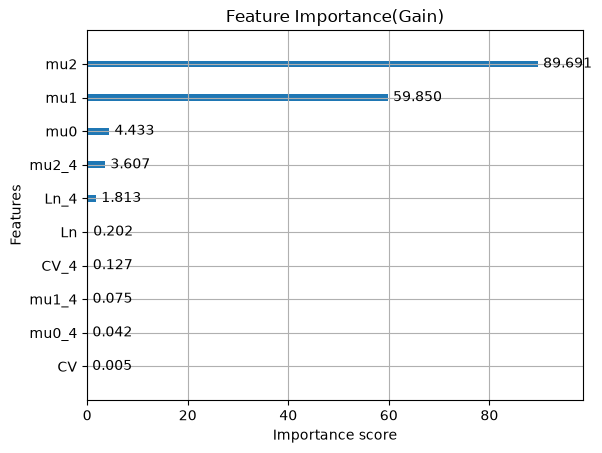

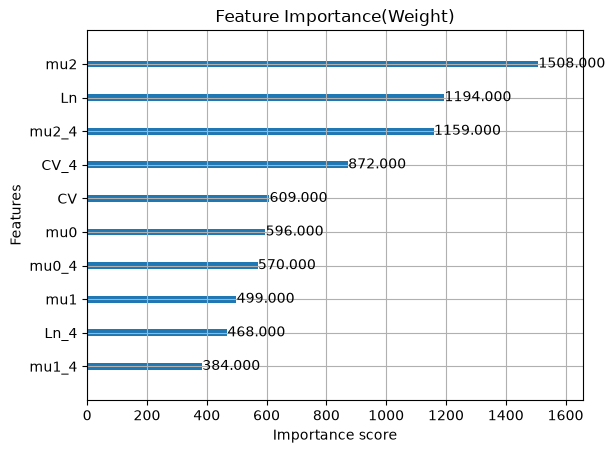

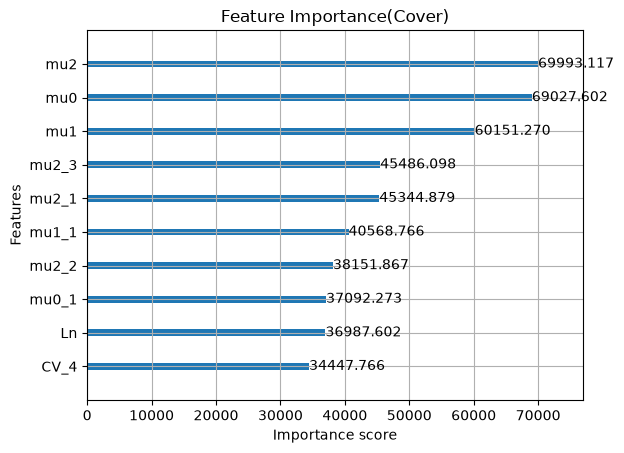

In [29]:
from xgboost import plot_importance

plot_importance(xgb_model, importance_type='gain', max_num_features=10, values_format="{v:.3f}", title='Feature Importance(Gain)') # Or weight, cover
plot_importance(xgb_model, importance_type='weight', max_num_features=10, values_format="{v:.3f}", title='Feature Importance(Weight)') # Or weight, cover
plot_importance(xgb_model, importance_type='cover', max_num_features=10, values_format="{v:.3f}", title='Feature Importance(Cover)') # Or weight, cover

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# 2. Define Model and Search Space
xgb_model = xgb.XGBRegressor()
param_dist = {
    "n_estimators": randint(50, 500),
    "max_depth": randint(3, 10),
    "learning_rate": uniform(0.01, 0.3),
    "subsample": uniform(0.5, 0.5),
    "colsample_bytree": uniform(0.5, 0.5)
}

# 3. Configure Randomized Search
search = RandomizedSearchCV(xgb_model, param_dist, n_iter=100, cv=5, n_jobs=-1)

# 4. Fit and Evaluate
search.fit(X_train, y_train)
print("Best Params:", search.best_params_)
# print("Best Score:", search.best_score_)

from sklearn.metrics import root_mean_squared_error, r2_score

y_pred = search.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {rmse}")
print(f"R2: {rmse}")

Best Params: {'colsample_bytree': np.float64(0.8471603766022655), 'learning_rate': np.float64(0.04107385957988217), 'max_depth': 9, 'n_estimators': 499, 'subsample': np.float64(0.5379558166160755)}
Best Score: 0.9999956250190735
RMSE: 0.0007468233816325665


In [32]:
from sklearn.metrics import root_mean_squared_error, r2_score

y_pred = search.best_estimator_.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {rmse}")
print(f"R2: {r2}")

RMSE: 0.0007468233816325665
R2: 0.9999958276748657
